In [2]:
import numpy as np
import pandas as pd

In [6]:
df=pd.read_csv("C:\\Users\\bluem\\Desktop\\Retail_Demand_Forecasting\\data\\smartretail_demand_data.csv")

In [7]:
df.head()

,Date,Product_ID,Product_Category,City,Store_Type,Price,Discount_Percentage,Marketing_Spend,Holiday_Flag,Previous_Month_Demand,Season,Next_Month_Demand
0,2025-05-01,FASH104,Fashion,Chennai,Mall,2869.75,0,4568.26,No,476,Summer,447
1,2024-10-01,CARE102,Personal Care,Kolkata,Neighbourhood,552.65,25,29789.71,Yes,549,Festival,1219
2,2025-01-01,ELEC103,Electronics,Mumbai,Supermarket,7501.15,0,12891.77,Yes,296,Winter,395
3,2023-03-01,CARE103,Personal Care,Pune,Mall,153.72,10,28439.45,No,732,Summer,710
4,2023-09-01,GROC101,Groceries,Bengaluru,Neighbourhood,126.60,5,19469.91,No,965,Festival,1283


In [9]:
df.shape

(3015, 12)

In [10]:
df.describe()

,Price,Discount_Percentage,Marketing_Spend,Previous_Month_Demand,Next_Month_Demand
count,3002.000000,3015.000000,3003.000000,3015.000000,3015.000000
mean,5319.844270,10.361526,16895.855981,484.776451,578.535323
std,7065.784275,7.342822,10104.850876,346.334666,387.313699
min,68.240000,0.000000,3008.360000,67.000000,62.000000
25%,398.912500,5.000000,10051.420000,182.000000,257.000000
50%,1969.450000,10.000000,16633.940000,382.000000,459.000000
75%,7596.892500,15.000000,23320.070000,741.000000,837.000000
max,28704.980000,25.000000,258128.037100,1601.000000,2336.000000


In [11]:
df.dtypes

Date                      object
Product_ID                object
Product_Category          object
City                      object
Store_Type                object
Price                    float64
Discount_Percentage        int64
Marketing_Spend          float64
Holiday_Flag              object
Previous_Month_Demand      int64
Season                    object
Next_Month_Demand          int64
dtype: object

In [12]:
df.isnull().sum()

Date                      0
Product_ID                0
Product_Category          0
City                     12
Store_Type                0
Price                    13
Discount_Percentage       0
Marketing_Spend          12
Holiday_Flag              0
Previous_Month_Demand     0
Season                    0
Next_Month_Demand         0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(15)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3015 entries, 0 to 3014
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   3015 non-null   object 
 1   Product_ID             3015 non-null   object 
 2   Product_Category       3015 non-null   object 
 3   City                   3003 non-null   object 
 4   Store_Type             3015 non-null   object 
 5   Price                  3002 non-null   float64
 6   Discount_Percentage    3015 non-null   int64  
 7   Marketing_Spend        3003 non-null   float64
 8   Holiday_Flag           3015 non-null   object 
 9   Previous_Month_Demand  3015 non-null   int64  
 10  Season                 3015 non-null   object 
 11  Next_Month_Demand      3015 non-null   int64  
dtypes: float64(2), int64(3), object(7)
memory usage: 282.8+ KB


In [15]:
df.describe(include="all")

,Date,Product_ID,Product_Category,City,Store_Type,Price,Discount_Percentage,Marketing_Spend,Holiday_Flag,Previous_Month_Demand,Season,Next_Month_Demand
count,3015,3015,3015,3003,3015,3002.000000,3015.000000,3003.000000,3015,3015.000000,3015,3015.000000
unique,36,20,5,8,4,NaN,NaN,NaN,2,NaN,4,NaN
top,2024-05-01,HOME104,Home Appliances,Pune,Mall,NaN,NaN,NaN,No,NaN,Summer,NaN
freq,98,169,620,391,790,NaN,NaN,NaN,2224,NaN,759,NaN
mean,NaN,NaN,NaN,NaN,NaN,5319.844270,10.361526,16895.855981,NaN,484.776451,NaN,578.535323
std,NaN,NaN,NaN,NaN,NaN,7065.784275,7.342822,10104.850876,NaN,346.334666,NaN,387.313699
min,NaN,NaN,NaN,NaN,NaN,68.240000,0.000000,3008.360000,NaN,67.000000,NaN,62.000000
25%,NaN,NaN,NaN,NaN,NaN,398.912500,5.000000,10051.420000,NaN,182.000000,NaN,257.000000
50%,NaN,NaN,NaN,NaN,NaN,1969.450000,10.000000,16633.940000,NaN,382.000000,NaN,459.000000
75%,NaN,NaN,NaN,NaN,NaN,7596.892500,15.000000,23320.070000,NaN,741.000000,NaN,837.000000


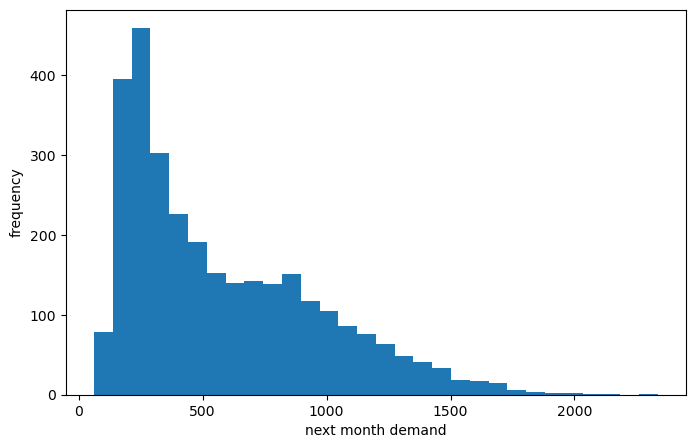

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df['Next_Month_Demand'],bins=30)
plt.xlabel("next month demand")
plt.ylabel("frequency")
plt.show()

In [17]:
print(df["Product_Category"].value_counts())

Product_Category
Home Appliances    620
Personal Care      607
Electronics        598
Fashion            595
Groceries          595
Name: count, dtype: int64


In [18]:
print(df["City"].value_counts())

City
Pune         391
Kolkata      390
Delhi        377
Hyderabad    376
Mumbai       370
Kochi        369
Bengaluru    368
Chennai      362
Name: count, dtype: int64


In [19]:
print(df["Store_Type"].value_counts())

Store_Type
Mall             790
Supermarket      761
Neighbourhood    738
High Street      726
Name: count, dtype: int64


In [20]:
print(df["Season"].value_counts())

Season
Summer      759
Festival    759
Winter      753
Monsoon     744
Name: count, dtype: int64


In [21]:
print(df.select_dtypes(include="number").corr()["Next_Month_Demand"].sort_values(ascending=False))

Next_Month_Demand        1.000000
Previous_Month_Demand    0.924799
Discount_Percentage      0.128573
Marketing_Spend          0.050097
Price                   -0.567428
Name: Next_Month_Demand, dtype: float64


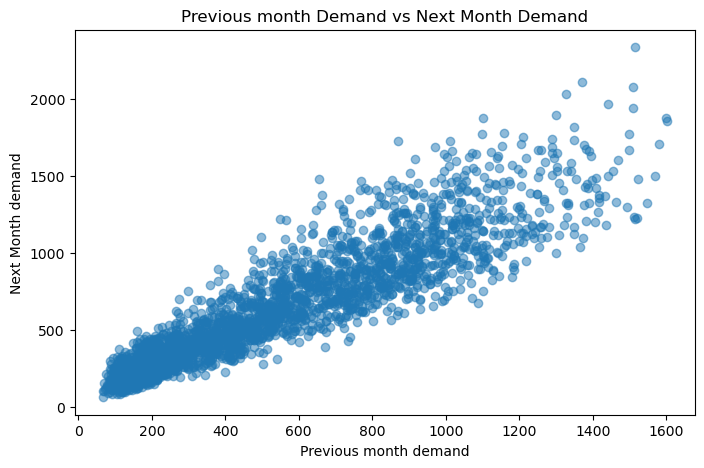

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.scatter(
    df["Previous_Month_Demand"],
    df["Next_Month_Demand"],
    alpha=0.5
)
plt.xlabel("Previous month demand")
plt.ylabel("Next Month demand")
plt.title("Previous month Demand vs Next Month Demand")
plt.show()

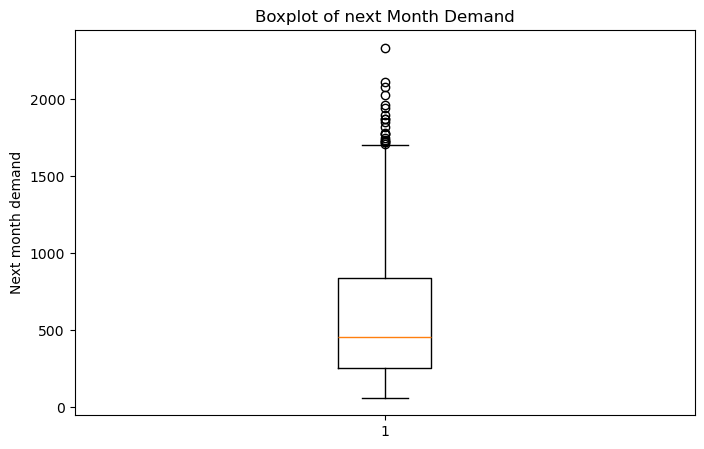

count    3015.000000
mean      578.535323
std       387.313699
min        62.000000
25%       257.000000
50%       459.000000
75%       837.000000
max      2336.000000
Name: Next_Month_Demand, dtype: float64


In [23]:
plt.figure(figsize=(8,5))
plt.boxplot(df['Next_Month_Demand'].dropna())
plt.ylabel("Next month demand")
plt.title("Boxplot of next Month Demand")
plt.show()
print(df['Next_Month_Demand'].describe())

In [24]:
df["Date"]=pd.to_datetime(df["Date"],errors="coerce")

In [25]:
df=df.drop_duplicates()

In [26]:
df["Price"]=df["Price"].fillna(df["Price"].median())
df["Marketing_Spend"]=df["Marketing_Spend"].fillna(df["Price"].median())
df["City"]=df["City"].fillna("Unknown")

print("Missing values:")
print(df.isnull().sum())
df=df.drop_duplicates()
print("duplicate values:",
df.duplicated().sum())
df.shape

Missing values:
Date                     0
Product_ID               0
Product_Category         0
City                     0
Store_Type               0
Price                    0
Discount_Percentage      0
Marketing_Spend          0
Holiday_Flag             0
Previous_Month_Demand    0
Season                   0
Next_Month_Demand        0
dtype: int64
duplicate values: 0


(3000, 12)

In [27]:
df.columns

Index(['Date', 'Product_ID', 'Product_Category', 'City', 'Store_Type', 'Price',
       'Discount_Percentage', 'Marketing_Spend', 'Holiday_Flag',
       'Previous_Month_Demand', 'Season', 'Next_Month_Demand'],
      dtype='object')

In [28]:
df.head(3)

,Date,Product_ID,Product_Category,City,Store_Type,Price,Discount_Percentage,Marketing_Spend,Holiday_Flag,Previous_Month_Demand,Season,Next_Month_Demand
0,2025-05-01,FASH104,Fashion,Chennai,Mall,2869.75,0,4568.26,No,476,Summer,447
1,2024-10-01,CARE102,Personal Care,Kolkata,Neighbourhood,552.65,25,29789.71,Yes,549,Festival,1219
2,2025-01-01,ELEC103,Electronics,Mumbai,Supermarket,7501.15,0,12891.77,Yes,296,Winter,395


In [29]:
df.to_csv("smartretail_cleaned.csv",index=False)